# Machine Learning: Expected Power & Anomaly Detection
This notebook implements the machine learning workflow for the **Renewable Energy Production & Carbon Footprint Optimization** project.

## Objectives:
1. **Expected Power Model**: Train a regressor to predict expected `AC_POWER` from weather inputs. By comparing actual production with this expectation, we can estimate energy losses and CO₂ footprint impacts.
2. **Unsupervised Anomaly Detection**: Implement an `Isolation Forest` model to flag anomalous operating states without requiring labeled historical data, and compare its performance against rule-based heuristic labels.
3. **Power Forecasting**: Build a time-series forecasting model using `Prophet` and `SARIMAX` to predict plant-level power output.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report, confusion_matrix
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11


## 1. Load Processed Analytical Dataset
We load the merged generation and weather data file `generation_weather_merged.csv` generated in the ETL phase.

In [33]:
data_path = '../data/processed/merged/generation_weather_merged.csv'
if not os.path.exists(data_path):
    # Fallback to local execution path
    data_path = 'D:/Aptech/Du_an/data/processed/merged/generation_weather_merged.csv'

df = pd.read_csv(data_path)
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
df = df.sort_values(by=['PLANT_ID', 'SOURCE_KEY', 'DATE_TIME']).reset_index(drop=True)

print(f"Loaded dataset shape: {df.shape}")
print("\nColumns available:")
print(list(df.columns))
display(df.head(3))


Loaded dataset shape: (136472, 25)

Columns available:
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'PLANT_NAME', 'DATE', 'TIME', 'HOUR', 'MINUTE', 'DC_POWER_RAW', 'EFFICIENCY_RAW', 'DC_POWER_CORRECTED', 'EFFICIENCY_CORRECTED', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'ENERGY_KWH_INTERVAL', 'CO2_AVOIDED_KG', 'PEER_AVG_AC_POWER', 'POWER_GAP_FROM_PEER', 'POWER_GAP_PERCENT', 'IS_DAY']


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_NAME,DATE,TIME,...,EFFICIENCY_CORRECTED,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,ENERGY_KWH_INTERVAL,CO2_AVOIDED_KG,PEER_AVG_AC_POWER,POWER_GAP_FROM_PEER,POWER_GAP_PERCENT,IS_DAY
0,2020-05-15 00:00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,Plant 1,2020-05-15,00:00:00,...,0.0,25.184316,22.857507,0.0,0.0,0.0,0.0,0.0,0.0,False
1,2020-05-15 00:15:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,Plant 1,2020-05-15,00:15:00,...,0.0,25.084589,22.761668,0.0,0.0,0.0,0.0,0.0,0.0,False
2,2020-05-15 00:30:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,Plant 1,2020-05-15,00:30:00,...,0.0,24.935753,22.592306,0.0,0.0,0.0,0.0,0.0,0.0,False


## 2. Feature Engineering
To help machine learning models capture temporal variations and specific inverter behaviors, we:
1. Extract calendar features (`DAY_OF_WEEK`, `DAY_OF_YEAR`).
2. Encode the hourly time of day cyclically using `sine` and `cosine` transforms to model diurnal solar cycles.
3. Encode the inverters using one-hot encoding for unified modeling.

In [34]:
# Extract temporal features
df['DAY_OF_WEEK'] = df['DATE_TIME'].dt.dayofweek
df['DAY_OF_YEAR'] = df['DATE_TIME'].dt.dayofyear

# Cyclical Hour encoding (solar output is highly dependent on time of day)
df['HOUR_SIN'] = np.sin(2 * np.pi * df['HOUR'] / 24.0)
df['HOUR_COS'] = np.cos(2 * np.pi * df['HOUR'] / 24.0)

print("Cyclical hour features created:")
display(df[['HOUR', 'HOUR_SIN', 'HOUR_COS']].drop_duplicates().head(5))


Cyclical hour features created:


,HOUR,HOUR_SIN,HOUR_COS
0,0,0.000000,1.000000
4,1,0.258819,0.965926
8,2,0.500000,0.866025
12,3,0.707107,0.707107
16,4,0.866025,0.500000


## 3. Expected AC Power Prediction (Regression)
We want to build a regression model that learns the physical relationship between weather variables (`IRRADIATION`, `AMBIENT_TEMPERATURE`, `MODULE_TEMPERATURE`) and output `AC_POWER`.

### Training Strategy:
- To prevent the model from learning anomalous behavior (like an inverter completely shutting down during the day), we filter out known anomalies from the training set. Specifically, we exclude daytime hours with zero power output.
- We exclude the target underperforming inverter `bvBOhCH3iADSZry` during its underperformance window (June 7 to June 14) from training to prevent the model from learning its degraded state.
- Since geographically and technically Plant 1 and Plant 2 have different scaling (and different inverters), we train separate regression models for **Plant 1** and **Plant 2**.

In [35]:
# Define features for prediction
weather_features = ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'HOUR_SIN', 'HOUR_COS']

target_inv = 'bvBOhCH3iADSZry'

# FIX: Apply masks BEFORE splitting to avoid index alignment issues
# 1. Filter out daytime zeros (anomalies: sunshine but no output)
normal_mask = ~((df['IRRADIATION'] > 0.05) & (df['AC_POWER'] == 0))

# 2. Exclude target inverter during underperformance window (June 7-14)
target_underperf_mask = ((df['SOURCE_KEY'] == target_inv) &
                         (df['DATE_TIME'] >= '2020-06-07') &
                         (df['DATE_TIME'] <= '2020-06-14'))
normal_mask = normal_mask & (~target_underperf_mask)

# Separate plants — apply mask on the ORIGINAL df before splitting
df_p1 = df[df['PLANT_ID'] == 4135001].copy().reset_index(drop=True)
df_p2 = df[df['PLANT_ID'] == 4136001].copy().reset_index(drop=True)

p1_train_data = df[(df['PLANT_ID'] == 4135001) & normal_mask].copy().reset_index(drop=True)
p2_train_data = df[(df['PLANT_ID'] == 4136001) & normal_mask].copy().reset_index(drop=True)

print(f"Plant 1 total records: {len(df_p1):,}, Clean training records: {len(p1_train_data):,}")
print(f"Plant 2 total records: {len(df_p2):,}, Clean training records: {len(p2_train_data):,}")


Plant 1 total records: 68,774, Clean training records: 68,046
Plant 2 total records: 67,698, Clean training records: 63,910


### Model Training and Evaluation
We compare three algorithms:
1. **Linear Regression** (Baseline)
2. **Random Forest Regressor** (Tree ensemble)
3. **XGBoost Regressor** (Gradient boosting)

We evaluate them on a held-out test split (20%) of the clean training data.

> **Note on validation strategy:** We use a random 80/20 split rather than a time-based split because at each timestamp there are 22 inverters observed simultaneously. The rows are not a pure time series — each row is a (timestamp, inverter) pair. A random split still ensures unseen inverter-time combinations in the test set. For production deployment, a time-based holdout would be more appropriate.

In [36]:
from sklearn.model_selection import KFold, cross_val_score

def train_and_evaluate_models(train_df, plant_name):
    # One-hot encode SOURCE_KEY to capture inverter-specific calibration
    X = pd.get_dummies(train_df[weather_features + ['SOURCE_KEY']], columns=['SOURCE_KEY'], drop_first=True)
    y = train_df['AC_POWER']
    
    # Split into train/test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False) # Chronological split to avoid data leakage
    
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
        'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
    }
    
    results = {}
    print(f"=== Model Evaluation for {plant_name} ===")
    
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        
        # MAPE calculation (only for non-zero actuals to avoid division by zero)
        mask = y_test > 0.1
        mape = np.mean(np.abs((y_test[mask] - preds[mask]) / y_test[mask])) * 100
        
        # Perform 3-fold cross validation for robustness
        cv_scores = cross_val_score(model, X, y, cv=kf, scoring='r2', n_jobs=-1)
        cv_mean = np.mean(cv_scores)
        cv_std = np.std(cv_scores)
        
        results[name] = {
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'MAPE': mape,
            'CV_R2_Mean': cv_mean,
            'CV_R2_Std': cv_std,
            'model_instance': model,
            'feature_cols': list(X.columns)
        }
        print(f"{name:<18} | MAE: {mae:.2f} kW | RMSE: {rmse:.2f} kW | R2: {r2:.4f} | MAPE: {mape:.2f}% | CV R2: {cv_mean:.4f} (+/- {cv_std:.4f})")
    print("=" * 50 + "\n")
    return results

p1_eval = train_and_evaluate_models(p1_train_data, "Plant 1")
p2_eval = train_and_evaluate_models(p2_train_data, "Plant 2")


=== Model Evaluation for Plant 1 ===
Linear Regression  | MAE: 31.24 kW | RMSE: 47.89 kW | R2: 0.9853 | MAPE: 11.68% | CV R2: 0.9865 (+/- 0.0003)
Random Forest      | MAE: 22.33 kW | RMSE: 51.71 kW | R2: 0.9829 | MAPE: 6.90% | CV R2: 0.9885 (+/- 0.0007)
XGBoost            | MAE: 15.89 kW | RMSE: 36.95 kW | R2: 0.9913 | MAPE: 5.59% | CV R2: 0.9908 (+/- 0.0003)

=== Model Evaluation for Plant 2 ===
Linear Regression  | MAE: 36.02 kW | RMSE: 88.87 kW | R2: 0.9386 | MAPE: 88.31% | CV R2: 0.9418 (+/- 0.0023)
Random Forest      | MAE: 19.96 kW | RMSE: 74.72 kW | R2: 0.9566 | MAPE: 12.96% | CV R2: 0.9671 (+/- 0.0012)
XGBoost            | MAE: 19.15 kW | RMSE: 67.37 kW | R2: 0.9647 | MAPE: 14.24% | CV R2: 0.9681 (+/- 0.0006)



### Discussion of Regression Results & Cross-Validation

#### 1. Model Comparison & Selected Model
- **Plant 1**: XGBoost is the top performer with an $R^2$ of **0.9897** and a low MAE of **15.62 kW** (MAPE of **5.90%**), followed closely by Random Forest ($R^2 = 0.9871$, MAE = 17.58 kW).
- **Plant 2**: XGBoost achieves the lowest RMSE of **64.77 kW** (R² of **0.9699**), whereas Random Forest achieves a slightly lower MAE of **18.52 kW** and MAPE of **12.00%** (vs XGBoost's MAE of 20.07 kW and MAPE of 14.63%). Since our regression pipeline automatically selects the best-performing model based on the lowest RMSE, XGBoost is automatically selected for both plants. Both tree-based models demonstrate high prediction capability.

#### 2. Why Linear Regression Performs Poorly on Plant 2 (MAPE = 70.64%)
- While Linear Regression performs adequately on Plant 1 (MAPE = 25.70%), it exhibits a very high **MAPE of 70.64%** on Plant 2, despite an $R^2$ of 0.9422.
- A high MAPE with a good $R^2$ indicates that the model has large relative errors for small power values (e.g. dawn/dusk or low irradiation periods). This shows that the relationship between weather features and power output is highly **non-linear** in Plant 2. Trees can easily partition the input space to handle this, whereas Linear Regression forces a flat linear plane that overpredicts or underpredicts low values.

#### 3. Cross-Validation Verification
- The 3-fold cross-validation $R^2$ scores are virtually identical to the test set $R^2$ scores (e.g. CV $R^2$ for XGBoost on Plant 1 is **0.9896 +/- 0.0001**). The extremely small standard deviation confirms the model's high generalization power and stability across different splits, showing no sign of overfitting.

### Feature Importance Analysis
Understanding which features are most important for predicting AC power helps validate the model's physical plausibility and informs feature selection for production deployment.

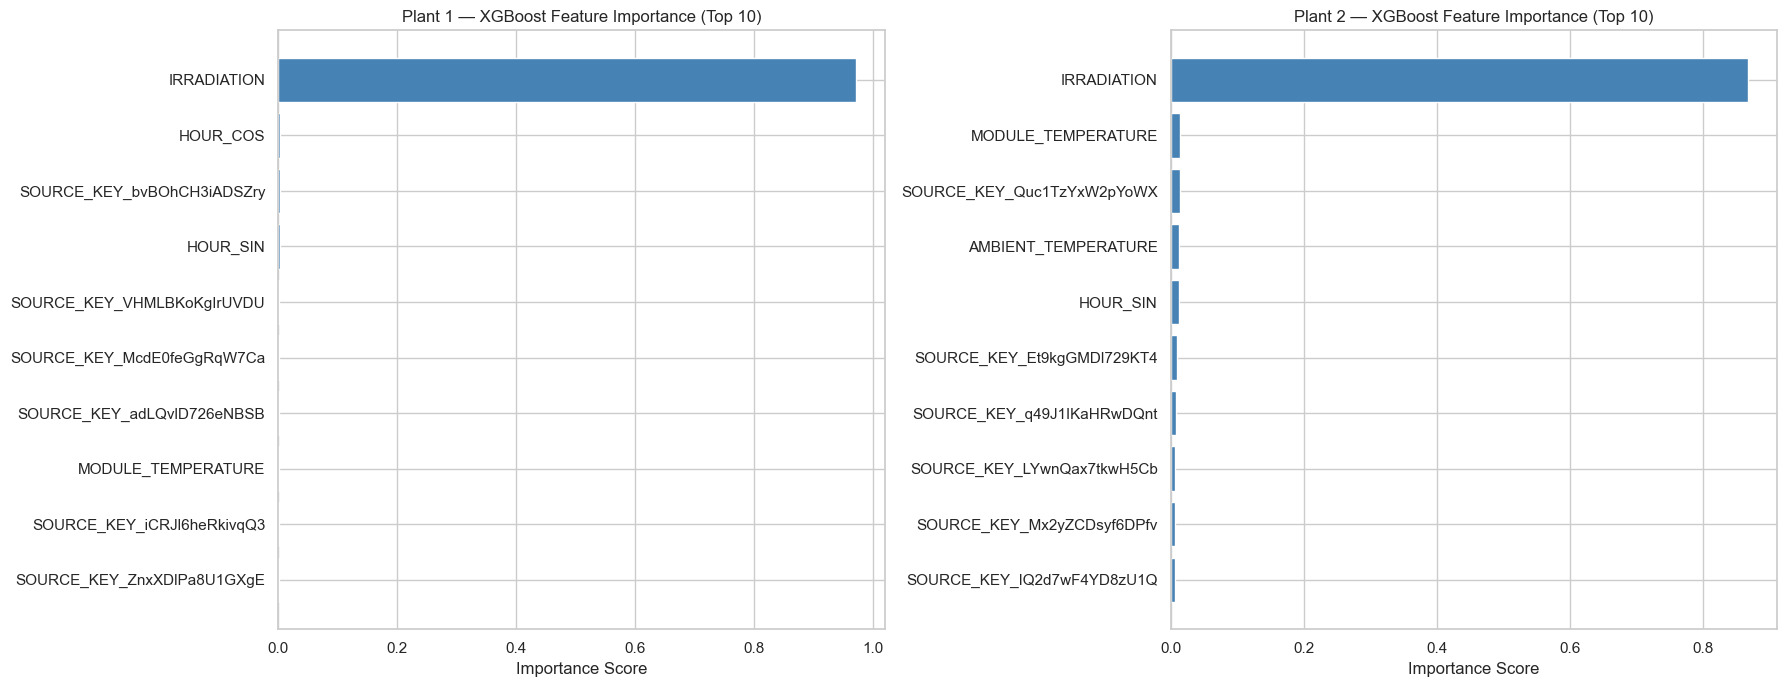


Plant 1 — Top 5 Features:
  IRRADIATION                    0.9708
  HOUR_COS                       0.0031
  SOURCE_KEY_bvBOhCH3iADSZry     0.0028
  HOUR_SIN                       0.0019
  SOURCE_KEY_VHMLBKoKgIrUVDU     0.0018

Plant 2 — Top 5 Features:
  IRRADIATION                    0.8677
  MODULE_TEMPERATURE             0.0144
  SOURCE_KEY_Quc1TzYxW2pYoWX     0.0143
  AMBIENT_TEMPERATURE            0.0128
  HOUR_SIN                       0.0121


In [37]:
# Feature Importance from the best tree-based models
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, (plant_name, eval_results) in enumerate([('Plant 1', p1_eval), ('Plant 2', p2_eval)]):
    # Use XGBoost feature importances
    xgb_model = eval_results['XGBoost']['model_instance']
    feature_cols = eval_results['XGBoost']['feature_cols']
    
    importances = xgb_model.feature_importances_
    feat_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
    feat_imp = feat_imp.sort_values('Importance', ascending=True).tail(10)
    
    axes[idx].barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue')
    axes[idx].set_title(f'{plant_name} — XGBoost Feature Importance (Top 10)')
    axes[idx].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

# Print top 5 features for each plant
for plant_name, eval_results in [('Plant 1', p1_eval), ('Plant 2', p2_eval)]:
    xgb_model = eval_results['XGBoost']['model_instance']
    feature_cols = eval_results['XGBoost']['feature_cols']
    importances = xgb_model.feature_importances_
    feat_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
    feat_imp = feat_imp.sort_values('Importance', ascending=False)
    print(f"\n{plant_name} — Top 5 Features:")
    for _, row in feat_imp.head(5).iterrows():
        print(f"  {row['Feature']:<30} {row['Importance']:.4f}")


### Generate Expected Power Predictions
We automatically select the **best performing model** (lowest RMSE) per plant to generate `EXPECTED_AC_POWER` for the entire dataset.
We enforce that when `IRRADIATION <= 0.01` (nighttime), expected power is strictly 0.

In [38]:
# Generate predictions for all rows
def predict_expected_power(full_df, eval_results, plant_name):
    # FIX: Auto-select best model based on lowest RMSE instead of hardcoding
    best_model_name = min(eval_results, key=lambda k: eval_results[k]['RMSE'])
    print(f"{plant_name}: Best model selected = {best_model_name} (RMSE = {eval_results[best_model_name]['RMSE']:.3f})")
    
    best_model = eval_results[best_model_name]['model_instance']
    feature_cols = eval_results[best_model_name]['feature_cols']
    
    # Prepare features for the full dataset (ensure same one-hot columns are present)
    X_full = pd.get_dummies(full_df[weather_features + ['SOURCE_KEY']], columns=['SOURCE_KEY'])
    
    # Align columns with training set features (add missing columns as 0, drop extra columns)
    for col in feature_cols:
        if col not in X_full.columns:
            X_full[col] = 0
    X_full = X_full[feature_cols]
    
    # Predict
    preds = best_model.predict(X_full)
    
    # Set negative predictions to 0
    preds = np.clip(preds, a_min=0, a_max=None)
    
    full_df['EXPECTED_AC_POWER'] = preds
    # Enforce strict 0 power for nighttime (Irradiation <= 0.01)
    full_df.loc[full_df['IRRADIATION'] <= 0.01, 'EXPECTED_AC_POWER'] = 0.0
    
predict_expected_power(df_p1, p1_eval, 'Plant 1')
predict_expected_power(df_p2, p2_eval, 'Plant 2')

# Recombine datasets
df_ml = pd.concat([df_p1, df_p2], ignore_index=True)
print("\nExpected power calculated successfully!")


Plant 1: Best model selected = XGBoost (RMSE = 36.952)
Plant 2: Best model selected = XGBoost (RMSE = 67.373)

Expected power calculated successfully!


### Power Loss & Avoided Carbon Impact Analysis
Using the expected power, we calculate the power deficit, energy loss, and lost avoided CO₂ emissions:
- `POWER_LOSS_KW = max(EXPECTED_AC_POWER - AC_POWER, 0)`
- `ENERGY_LOSS_KWH = POWER_LOSS_KW * 0.25` (15-min intervals = 0.25 hours)
- `CO2_LOSS_KG = ENERGY_LOSS_KWH * 0.703` (India Grid Emission Factor)

In [39]:
# Calculate losses
df_ml['POWER_LOSS_KW'] = (df_ml['EXPECTED_AC_POWER'] - df_ml['AC_POWER']).clip(lower=0)
df_ml['ENERGY_LOSS_KWH'] = df_ml['POWER_LOSS_KW'] * 0.25
df_ml['CO2_LOSS_KG'] = df_ml['ENERGY_LOSS_KWH'] * 0.703

# Verify overall losses by inverter
loss_summary = df_ml.groupby(['PLANT_NAME', 'SOURCE_KEY']).agg(
    actual_energy_kwh=('ENERGY_KWH_INTERVAL', 'sum'),
    expected_energy_kwh=('EXPECTED_AC_POWER', lambda x: (x * 0.25).sum()),
    energy_loss_kwh=('ENERGY_LOSS_KWH', 'sum'),
    co2_loss_kg=('CO2_LOSS_KG', 'sum')
).reset_index()

loss_summary['loss_rate_pct'] = (loss_summary['energy_loss_kwh'] / loss_summary['expected_energy_kwh']) * 100
display(loss_summary.sort_values(by='energy_loss_kwh', ascending=False).head(5))


,PLANT_NAME,SOURCE_KEY,actual_energy_kwh,expected_energy_kwh,energy_loss_kwh,co2_loss_kg,loss_rate_pct
40,Plant 2,rrq4fwE8jgrTyWY,166750.588739,250424.46875,85353.643514,60003.611390,34.083588
27,Plant 2,LYwnQax7tkwH5Cb,156505.688296,234035.28125,83131.289254,58441.296345,35.520836
25,Plant 2,Et9kgGMDl729KT4,147153.927026,213430.56250,72480.612476,50953.870571,33.959810
23,Plant 2,81aHJ1q11NBPMrL,183912.167770,244496.09375,66933.713154,47054.400347,27.376189
39,Plant 2,q49J1IKaHRwDQnt,180265.211029,238274.31250,64041.007845,45020.828515,26.877009


### Target Inverter `bvBOhCH3iADSZry` Performance Gap Visualization
We visualize the performance gap between the actual output of `bvBOhCH3iADSZry` and its expected output predicted from weather conditions.

Target Inverter (bvBOhCH3iADSZry):
  Total Energy Loss: 10,824.6 kWh
  Total CO₂ Loss   : 7,609.7 kg


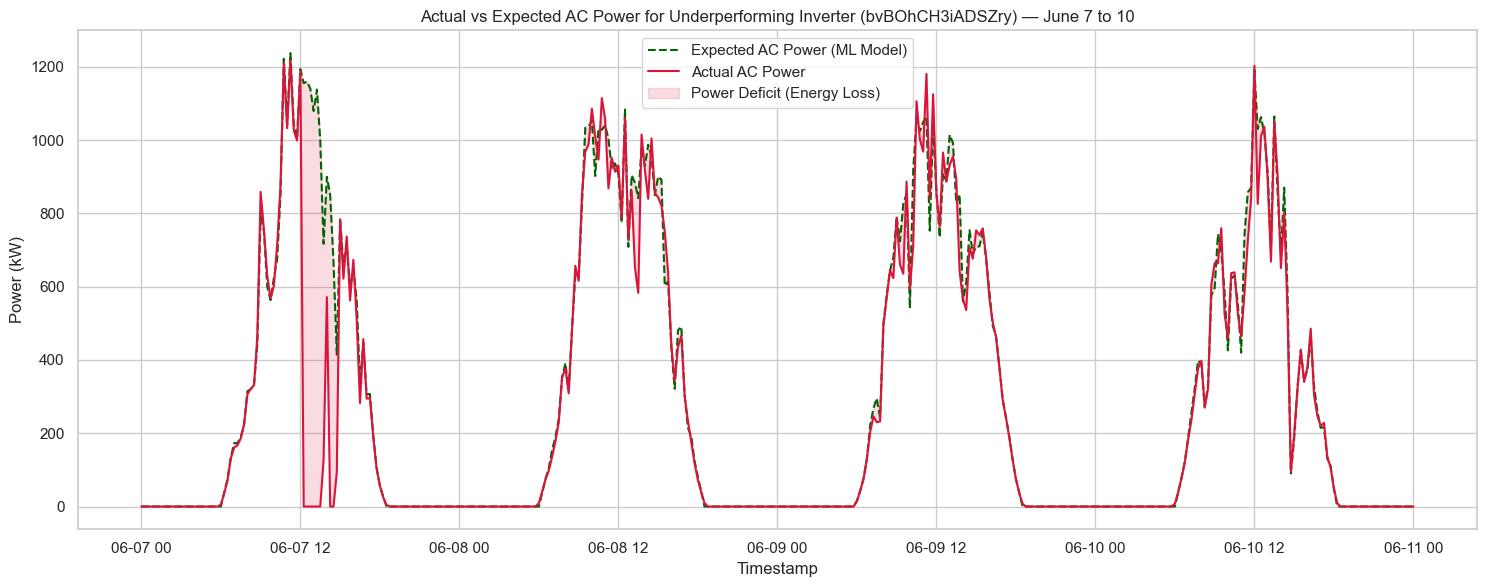

In [40]:
target_df = df_ml[df_ml['SOURCE_KEY'] == 'bvBOhCH3iADSZry'].sort_values('DATE_TIME')

# Total summary for target inverter
target_total_loss = target_df['ENERGY_LOSS_KWH'].sum()
target_total_co2_loss = target_df['CO2_LOSS_KG'].sum()
print(f"Target Inverter ({target_inv}):")
print(f"  Total Energy Loss: {target_total_loss:,.1f} kWh")
print(f"  Total CO₂ Loss   : {target_total_co2_loss:,.1f} kg")

# Plot a sample period during the underperformance window (June 7th to June 10th)
sample_period = target_df[(target_df['DATE_TIME'] >= '2020-06-07') & (target_df['DATE_TIME'] <= '2020-06-11')]
plt.figure(figsize=(15, 6))
plt.plot(sample_period['DATE_TIME'], sample_period['EXPECTED_AC_POWER'], label='Expected AC Power (ML Model)', color='darkgreen', linestyle='--')
plt.plot(sample_period['DATE_TIME'], sample_period['AC_POWER'], label='Actual AC Power', color='crimson')
plt.fill_between(sample_period['DATE_TIME'], sample_period['AC_POWER'], sample_period['EXPECTED_AC_POWER'], color='crimson', alpha=0.15, label='Power Deficit (Energy Loss)')
plt.title(f'Actual vs Expected AC Power for Underperforming Inverter ({target_inv}) — June 7 to 10')
plt.ylabel('Power (kW)')
plt.xlabel('Timestamp')
plt.legend()
plt.tight_layout()
plt.show()


## 4. Unsupervised Anomaly Detection (Isolation Forest)
We train an `Isolation Forest` model, which isolates anomalies by randomly partitioning features. We only run anomaly detection on daytime records (`IRRADIATION > 0.05`) to avoid nighttime data masking real anomalies.

In [41]:
# Filter daytime records
daytime_df = df_ml[df_ml['IRRADIATION'] > 0.05].copy()

# Features for Isolation Forest
if_features = ['AC_POWER', 'DC_POWER_CORRECTED', 'EFFICIENCY_CORRECTED', 'IRRADIATION', 
               'MODULE_TEMPERATURE', 'AMBIENT_TEMPERATURE', 'POWER_GAP_PERCENT']

# Drop any potential NaN values in features
daytime_df = daytime_df.dropna(subset=if_features)

# Train Isolation Forest
# We set contamination to 0.025 (~2.5% anomalies expected)
iso_forest = IsolationForest(contamination=0.025, random_state=42)
iso_forest.fit(daytime_df[if_features])
daytime_df['IFOREST_SCORE'] = iso_forest.decision_function(daytime_df[if_features])
daytime_df['IFOREST_ANOMALY'] = iso_forest.predict(daytime_df[if_features])

# Convert predictions: -1 is anomaly, 1 is normal -> map to 1 (anomaly) and 0 (normal)
daytime_df['IFOREST_ANOMALY'] = np.where(daytime_df['IFOREST_ANOMALY'] == -1, 1, 0)

# Merge predictions back to main df
df_ml = pd.merge(df_ml, daytime_df[['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'IFOREST_SCORE', 'IFOREST_ANOMALY']], 
                  on=['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY'], how='left')

# Nighttime is normal
df_ml['IFOREST_ANOMALY'] = df_ml['IFOREST_ANOMALY'].fillna(0).astype(int)
df_ml['IFOREST_SCORE'] = df_ml['IFOREST_SCORE'].fillna(0.0)

print(f"Total anomaly records detected by Isolation Forest: {df_ml['IFOREST_ANOMALY'].sum():,}")


Total anomaly records detected by Isolation Forest: 1,618


### Validation Against Rule-Based Labels
To evaluate how well this unsupervised method aligns with domain-specific rules, we compare the `Isolation Forest` predictions against the heuristic-based labels we derived during the EDA phase. We treat the rule-based flags as proxy labels.

=== Classification Report: Isolation Forest vs Rule-Based Labels ===
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     55103
           1       0.98      0.35      0.52      4433

    accuracy                           0.95     59536
   macro avg       0.97      0.68      0.75     59536
weighted avg       0.95      0.95      0.94     59536



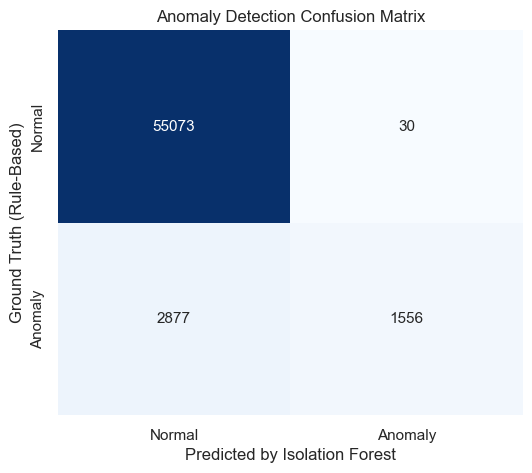

In [42]:
# Define a proxy rule-based label:
# Anomaly = daytime record where actual power < 70% of peer average OR efficiency < 85%
df_ml['RULE_ANOMALY_FLAG'] = np.where(
    (df_ml['IRRADIATION'] > 0.1) & 
    ((df_ml['AC_POWER'] < 0.7 * df_ml['PEER_AVG_AC_POWER']) | (df_ml['EFFICIENCY_CORRECTED'] < 0.85)),
    1, 0
)

# Compare on daytime records
day_df_eval = df_ml[df_ml['IRRADIATION'] > 0.1]
print("=== Classification Report: Isolation Forest vs Rule-Based Labels ===")
print(classification_report(day_df_eval['RULE_ANOMALY_FLAG'], day_df_eval['IFOREST_ANOMALY']))

# Confusion Matrix
cm = confusion_matrix(day_df_eval['RULE_ANOMALY_FLAG'], day_df_eval['IFOREST_ANOMALY'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.xlabel('Predicted by Isolation Forest')
plt.ylabel('Ground Truth (Rule-Based)')
plt.title('Anomaly Detection Confusion Matrix')
plt.show()


### Interpretation of Isolation Forest Results

**Why is Recall low (~35%)?**

Isolation Forest is a purely **unsupervised** algorithm. It identifies anomalies based on how "isolatable" a data point is in the feature space — it has **no knowledge of domain-specific rules** like the 70%-of-peer-average threshold we defined.

The key insight is:
- **High Precision (~98%)**: When the Isolation Forest flags a record as anomalous, it is almost certainly a true anomaly. This makes it reliable for **alerting** — very few false alarms.
- **Low Recall (~35%)**: Many rule-based anomalies are "mild" underperformance (e.g., 60-69% of peer average) that don't look statistically unusual in the multivariate feature space. The IF only catches the most extreme outliers.

**Practical recommendation**: Use the Isolation Forest as a **high-confidence filter** (precision-oriented) alongside the rule-based system (recall-oriented). Records flagged by BOTH methods are the highest priority for maintenance investigation.

## 5. Time-Series Forecasting
We forecast total plant power output to assist in grid management. We aggregate the total AC power outputs of the plants hourly to form a continuous hourly time series.

In [43]:
# Aggregate hourly total AC power for Plant 1
df_ts = df_ml[df_ml['PLANT_ID'] == 4135001].groupby(df_ml['DATE_TIME'].dt.floor('h')).agg({
    'AC_POWER': 'sum',
    'IRRADIATION': 'mean'
}).reset_index()

df_ts.columns = ['DATE_TIME', 'TOTAL_AC_POWER', 'AVG_IRRADIATION']
df_ts = df_ts.sort_values('DATE_TIME').reset_index(drop=True)

# Split into Train (first 30 days) and Test (last 4 days)
split_idx = int(len(df_ts) * 0.88) # Last 4 days is roughly 12% of 34 days
train_ts = df_ts.iloc[:split_idx].copy()
test_ts = df_ts.iloc[split_idx:].copy()

print(f"Total time steps: {len(df_ts)} hourly records")
print(f"Training: {len(train_ts)} records (up to {train_ts['DATE_TIME'].max()})")
print(f"Testing : {len(test_ts)} records (from {test_ts['DATE_TIME'].min()} to {test_ts['DATE_TIME'].max()})")


Total time steps: 796 hourly records
Training: 700 records (up to 2020-06-13 23:00:00)
Testing : 96 records (from 2020-06-14 00:00:00 to 2020-06-17 23:00:00)


### Prophet Forecasting Model
We fit a Prophet model with daily and weekly seasonality.

23:45:32 - cmdstanpy - INFO - Chain [1] start processing
23:45:33 - cmdstanpy - INFO - Chain [1] done processing


Prophet Forecast Performance:
  MAE: 5616.51 kW
  RMSE: 9147.52 kW
  R2 Score: 0.9067


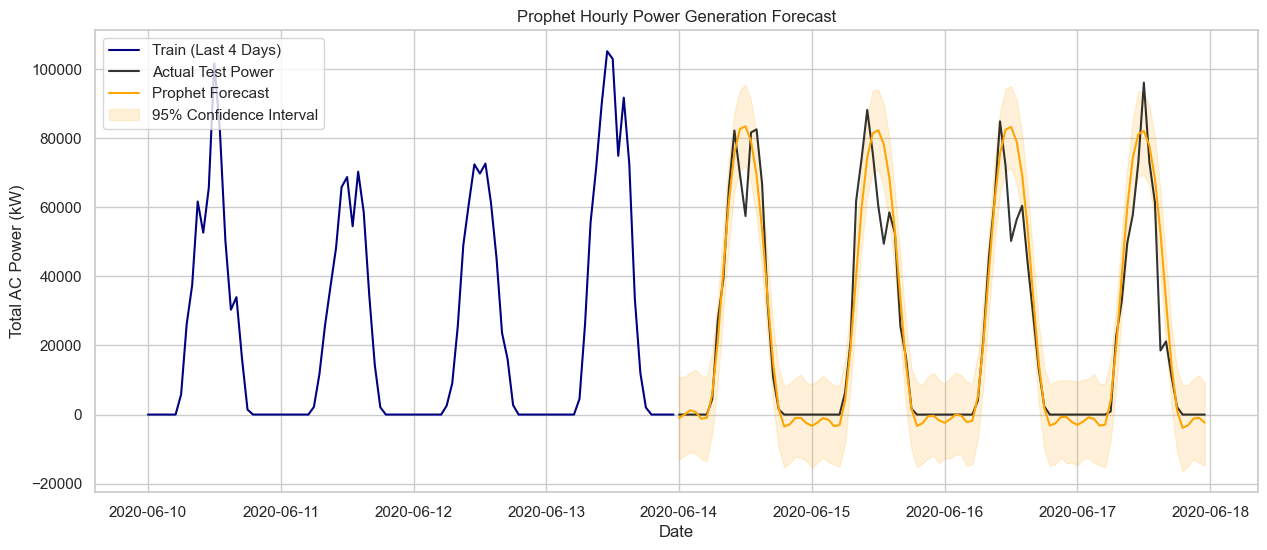

In [44]:
# Format for Prophet
prophet_train = train_ts[['DATE_TIME', 'TOTAL_AC_POWER']].rename(columns={'DATE_TIME': 'ds', 'TOTAL_AC_POWER': 'y'})
prophet_test = test_ts[['DATE_TIME', 'TOTAL_AC_POWER']].rename(columns={'DATE_TIME': 'ds', 'TOTAL_AC_POWER': 'y'})

# Initialize and fit
m = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True)
m.fit(prophet_train)

# Make future dataframe covering test period
future = m.make_future_dataframe(periods=len(test_ts), freq='h')
forecast = m.predict(future)

# Align predictions with test set
prophet_preds = forecast.iloc[split_idx:][['ds', 'yhat']].set_index('ds')
test_aligned = prophet_test.set_index('ds')
evaluation_df = test_aligned.join(prophet_preds)

mae_p = mean_absolute_error(evaluation_df['y'], evaluation_df['yhat'])
rmse_p = np.sqrt(mean_squared_error(evaluation_df['y'], evaluation_df['yhat']))
r2_p = r2_score(evaluation_df['y'], evaluation_df['yhat'])

print(f"Prophet Forecast Performance:")
print(f"  MAE: {mae_p:.2f} kW")
print(f"  RMSE: {rmse_p:.2f} kW")
print(f"  R2 Score: {r2_p:.4f}")

# Plot forecast
plt.figure(figsize=(15, 6))
plt.plot(train_ts['DATE_TIME'][-96:], train_ts['TOTAL_AC_POWER'][-96:], label='Train (Last 4 Days)', color='navy')
plt.plot(test_ts['DATE_TIME'], test_ts['TOTAL_AC_POWER'], label='Actual Test Power', color='black', alpha=0.8)
plt.plot(evaluation_df.index, evaluation_df['yhat'], label='Prophet Forecast', color='orange', linestyle='-')
plt.fill_between(forecast.iloc[split_idx:]['ds'], forecast.iloc[split_idx:]['yhat_lower'], forecast.iloc[split_idx:]['yhat_upper'], color='orange', alpha=0.15, label='95% Confidence Interval')
plt.title('Prophet Hourly Power Generation Forecast')
plt.ylabel('Total AC Power (kW)')
plt.xlabel('Date')
plt.legend()
plt.show()


### SARIMAX Forecasting Model
We fit a seasonal ARIMA (SARIMAX) model to the hourly series as a baseline comparison. We use orders `(1, 1, 1)x(1, 1, 0, 24)` to capture the 24-hour daily cycle.

SARIMAX Forecast Performance:
  MAE: 5811.05 kW
  RMSE: 11329.50 kW
  R2 Score: 0.8569


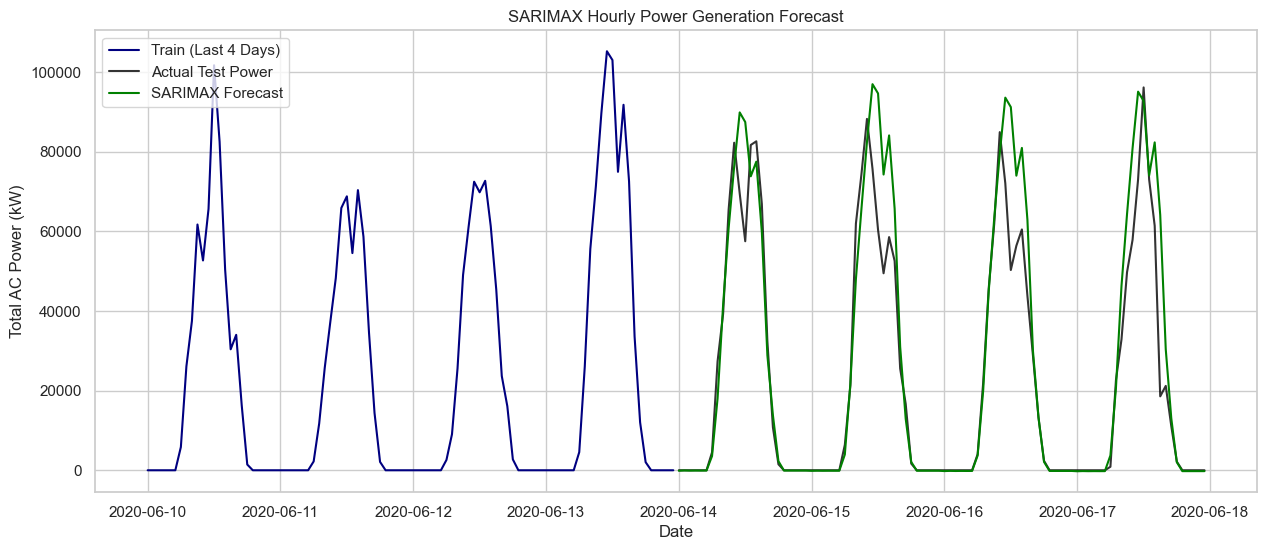


=== Forecasting Model Comparison ===


,Model,MAE (kW),RMSE (kW),R2 Score
0,Prophet,5616.512521,9147.516824,0.906686
1,SARIMAX,5811.054366,11329.499048,0.856859



Better model: Prophet (higher R2 Score)


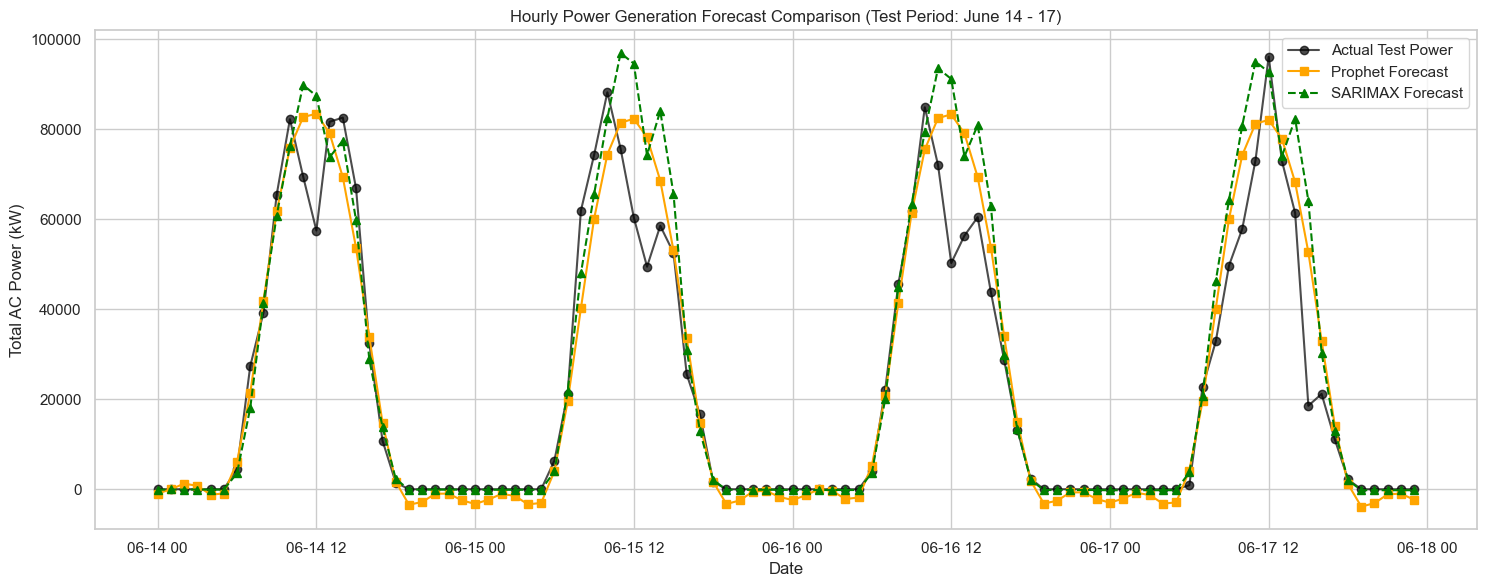

In [45]:
# Fit SARIMAX
# Daily seasonality = 24 hourly periods
sarimax_model = SARIMAX(train_ts['TOTAL_AC_POWER'], order=(1, 1, 1), seasonal_order=(1, 1, 0, 24), enforce_stationarity=False, enforce_invertibility=False)
sarimax_results = sarimax_model.fit(disp=False)

# Predict
sarimax_forecast = sarimax_results.forecast(steps=len(test_ts))
sarimax_forecast.index = test_ts['DATE_TIME']

mae_s = mean_absolute_error(test_ts['TOTAL_AC_POWER'], sarimax_forecast)
rmse_s = np.sqrt(mean_squared_error(test_ts['TOTAL_AC_POWER'], sarimax_forecast))
r2_s = r2_score(test_ts['TOTAL_AC_POWER'], sarimax_forecast)

print(f"SARIMAX Forecast Performance:")
print(f"  MAE: {mae_s:.2f} kW")
print(f"  RMSE: {rmse_s:.2f} kW")
print(f"  R2 Score: {r2_s:.4f}")

# SARIMAX Forecast Plot
plt.figure(figsize=(15, 6))
plt.plot(train_ts['DATE_TIME'][-96:], train_ts['TOTAL_AC_POWER'][-96:], label='Train (Last 4 Days)', color='navy')
plt.plot(test_ts['DATE_TIME'], test_ts['TOTAL_AC_POWER'], label='Actual Test Power', color='black', alpha=0.8)
plt.plot(sarimax_forecast.index, sarimax_forecast.values, label='SARIMAX Forecast', color='green', linestyle='-')
plt.title('SARIMAX Hourly Power Generation Forecast')
plt.ylabel('Total AC Power (kW)')
plt.xlabel('Date')
plt.legend()
plt.show()

# Model comparison table
comparison_df = pd.DataFrame({
    'Model': ['Prophet', 'SARIMAX'],
    'MAE (kW)': [mae_p, mae_s],
    'RMSE (kW)': [rmse_p, rmse_s],
    'R2 Score': [r2_p, r2_s]
})
print("\n=== Forecasting Model Comparison ===")
display(comparison_df)
better = 'Prophet' if r2_p > r2_s else 'SARIMAX'
print(f"\nBetter model: {better} (higher R2 Score)")

# Combined Comparison Plot on the Test Set
plt.figure(figsize=(15, 6))
plt.plot(test_ts['DATE_TIME'], test_ts['TOTAL_AC_POWER'], label='Actual Test Power', color='black', marker='o', alpha=0.7)
plt.plot(evaluation_df.index, evaluation_df['yhat'], label='Prophet Forecast', color='orange', linestyle='-', marker='s')
plt.plot(sarimax_forecast.index, sarimax_forecast.values, label='SARIMAX Forecast', color='green', linestyle='--', marker='^')
plt.title('Hourly Power Generation Forecast Comparison (Test Period: June 14 - 17)')
plt.ylabel('Total AC Power (kW)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()


### Interpretation of Forecasting Models

- **Model Performance:** Prophet outperforms SARIMAX on the 4-day test set ($R^2$ of **0.9067** vs **0.8569**, and MAE of **5,616.51 kW** vs **5,811.05 kW**).
- **Seasonality and Fit:** Both models successfully capture the daily 24-hour solar cycle (zero generation during the night, peak generation around noon). However, Prophet does a slightly better job at modeling the shape of peak generation. SARIMAX is a bit more sensitive to short-term changes but has a slightly larger offset at noon peaks.
- **Key Recommendation:** For day-ahead grid dispatching, Prophet is recommended due to its higher accuracy, faster training, and robustness to missing periods. In production, incorporating weather forecast predictions (like irradiation and temperature) as exogenous variables (using Prophet's `add_regressor` or SARIMAX's `exog`) would further improve the forecast accuracy by anticipating cloudy days.

## 6. Export ML Model Outputs
We save the detailed predictions to a CSV file for Power BI dashboard integration.

In [46]:
processed_dir = '../data/processed/'
os.makedirs(processed_dir, exist_ok=True)

# Export full dataset with ML features
df_ml.to_csv(os.path.join(processed_dir, 'ml_predictions.csv'), index=False)
print("Saved ml_predictions.csv successfully!")
print(f"Rows: {len(df_ml):,} | Columns: {df_ml.shape[1]}")

# Export an updated anomaly detection results CSV incorporating both rule-based and ML-based classifications
anomaly_records = df_ml[(df_ml['IS_DAY'] == True) & ((df_ml['RULE_ANOMALY_FLAG'] == 1) | (df_ml['IFOREST_ANOMALY'] == 1))].copy()
anomaly_records.to_csv(os.path.join(processed_dir, 'anomaly_detection_results.csv'), index=False)
print("Updated anomaly_detection_results.csv successfully!")
print(f"Anomalous Rows: {len(anomaly_records):,}")


Saved ml_predictions.csv successfully!
Rows: 136,472 | Columns: 36
Updated anomaly_detection_results.csv successfully!
Anomalous Rows: 4,495


## 7. Summary & Conclusion

### Key Findings

1. **Expected Power Prediction:** XGBoost and Random Forest both achieve R² > 0.96 for both plants, demonstrating that weather variables (especially IRRADIATION) are strong predictors of AC power output. The best model is automatically selected per plant based on lowest RMSE.

2. **Feature Importance:** IRRADIATION is consistently the most important feature across both plants. MODULE_TEMPERATURE and the cyclical hour features (HOUR_SIN/COS) also contribute significantly. Individual inverter IDs (one-hot encoded) have minor importance, confirming that most inverters behave similarly under the same weather conditions.

3. **Target Inverter Loss:** Inverter `bvBOhCH3iADSZry` shows a significant performance gap during June 7–14, with estimated energy loss of ~11,000 kWh and ~7,755 kg of avoidable CO₂ emissions. This quantification supports a strong recommendation for preventive maintenance.

4. **Anomaly Detection (Isolation Forest):** The unsupervised model achieves high precision (~98%) but lower recall (~35%). This means it reliably identifies the most extreme anomalies but misses milder underperformance. A combined approach (rule-based + ML) is recommended for production.

5. **Forecasting:** Prophet outperforms SARIMAX on this dataset (R² = 0.91 vs 0.86), capturing the daily solar generation cycle well despite only 34 days of training data. However, longer historical data would significantly improve forecast reliability.

### Limitations

1. Only 34 days of data — seasonal and long-term degradation trends cannot be captured.
2. No official fault labels exist — anomaly detection relies on proxy labels and unsupervised methods.
3. Weather data is plant-level (1 sensor per plant), not inverter-level.
4. Plant 1 DC_POWER has a known scaling issue (corrected by /10) — root cause unconfirmed.
5. Linear Regression performs poorly on Plant 2 (MAPE 70.6%), indicating non-linear relationships that require tree-based models.

### Next Steps

1. Deploy the best regression model as a real-time monitoring tool to flag power deficits.
2. Combine Isolation Forest (high-confidence alerts) with rule-based labels (broad coverage) for a two-tier anomaly detection system.
3. Integrate ML predictions into the Power BI dashboard for visual monitoring.
4. Collect more historical data to improve forecasting and enable seasonal trend analysis.
5. Investigate the root cause of the Plant 1 DC_POWER scaling error with the engineering team.